# Assistant
# Anaconda Assistant

This is a project using the Online Shoppers Purchasing Intention dataset with both TensorFlow and PyTorch. This dataset contains features of user sessions on an online shopping website, with the goal of predicting whether a user will make a purchase. Here is the dataset: https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset. 

## Project: Online Shopping Purchase Prediction

This project will demonstrate how to:
1. Load and preprocess the dataset
2. Build classification models in both TensorFlow and PyTorch
3. Evaluate and compare the models


Dataset shape: (12330, 18)

First 5 rows:
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00  

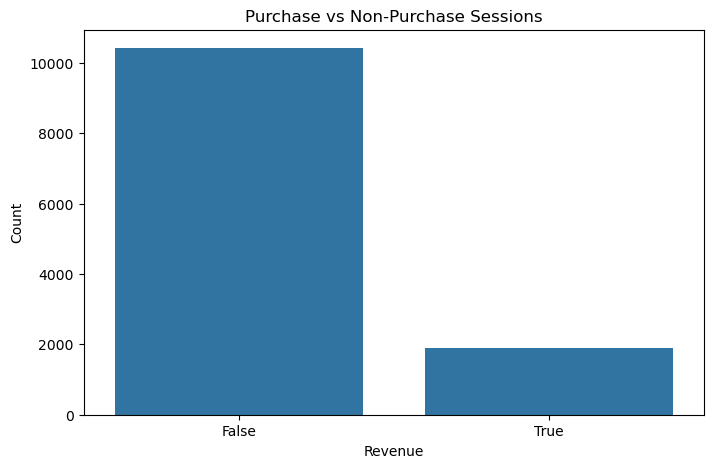

Number of features after preprocessing: 27

--- Building TensorFlow Model ---


C:\Users\aahan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8494 - auc: 0.8132 - loss: 0.3603 - val_accuracy: 0.8885 - val_auc: 0.8874 - val_loss: 0.2769
Epoch 2/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8881 - auc: 0.8842 - loss: 0.2798 - val_accuracy: 0.8870 - val_auc: 0.9034 - val_loss: 0.2615
Epoch 3/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8904 - auc: 0.8967 - loss: 0.2679 - val_accuracy: 0.8890 - val_auc: 0.9097 - val_loss: 0.2550
Epoch 4/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8913 - auc: 0.9088 - loss: 0.2556 - val_accuracy: 0.8895 - val_auc: 0.9121 - val_loss: 0.2510
Epoch 5/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8946 - auc: 0.9070 - loss: 0.2553 - val_accuracy: 0.8905 - val_auc: 0.9151 - val_loss: 0.2478
Epoch 6/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8996 - auc: 0.9166 - loss: 0.2455 - val_accuracy: 0.8910 - val_auc: 0.9167 - val_loss: 0.2450
Epoch 7/50
247/247 ━━━━━━━━━━━━━━━━━━━━

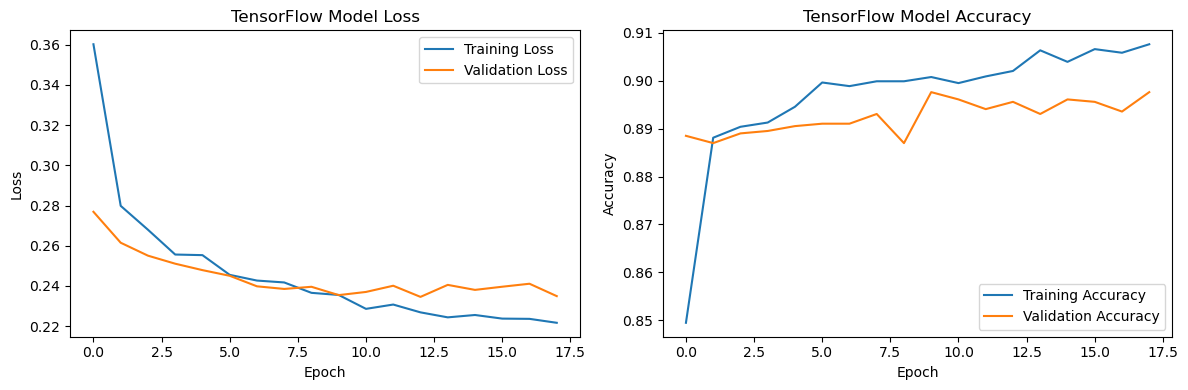

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

TensorFlow Model Results:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.71      0.56      0.62       382

    accuracy                           0.90      2466
   macro avg       0.82      0.76      0.78      2466
weighted avg       0.89      0.90      0.89      2466


--- Building PyTorch Model ---
Using device: cpu


AttributeError: 'Tensor' object has no attribute 'backwar'

In [17]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score
from sklearn.ensemble import RandomForestClassifier

# For deep learning
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
data = pd.read_csv(url)

# Exploratory Data Analysis
print("Dataset shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head())
print("\nData types and missing values:")
print(data.info())
print("\nSummary statistics:")
print(data.describe())

# Check class distribution
print("\nTarget variable distribution:")
print(data['Revenue'].value_counts(normalize=True))

# Visualize class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Revenue', data=data)
plt.title('Purchase vs Non-Purchase Sessions')
plt.ylabel('Count')
plt.show()

# Data Preprocessing
# Split features and target
X = data.drop('Revenue', axis=1)
y = data['Revenue'].astype(int)

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get the number of features after preprocessing
n_features = X_train_processed.shape[1]
print(f"Number of features after preprocessing: {n_features}")

# Part 1: TensorFlow Model
print("\n--- Building TensorFlow Model ---")

# Define the model
def build_tf_model(n_features):
    model = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(n_features,)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC()])
    return model

# Create and train the model
tf_model = build_tf_model(n_features)
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

tf_history = tf_model.fit(
    X_train_processed, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(tf_history.history['loss'], label='Training Loss')
plt.plot(tf_history.history['val_loss'], label='Validation Loss')
plt.title('TensorFlow Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(tf_history.history['accuracy'], label='Training Accuracy')
plt.plot(tf_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('TensorFlow Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Evaluate TensorFlow model
y_pred_proba_tf = tf_model.predict(X_test_processed)
y_pred_tf = (y_pred_proba_tf > 0.5).astype(int)
print("\nTensorFlow Model Results:")
print(classification_report(y_test, y_pred_tf))

# Part 2: PyTorch Model
print("\n--- Building PyTorch Model ---")

# Create PyTorch dataset
class ShopperDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32).reshape(-1, 1)
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Create datasets and dataloaders
train_dataset = ShopperDataset(X_train_processed, y_train.values)
test_dataset = ShopperDataset(X_test_processed, y_test.values)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define PyTorch model
class PurchasePredictor(nn.Module):
    def __init__(self, n_features):
        super(PurchasePredictor, self).__init__()
        self.layer1 = nn.Linear(n_features, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.layer2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.layer3 = nn.Linear(64, 32)
        self.layer4 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        self.dropout2 = nn.Dropout(0.2)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.dropout1(self.bn1(self.relu(self.layer1(x))))
        x = self.dropout2(self.bn2(self.relu(self.layer2(x))))
        x = self.relu(self.layer3(x))
        x = self.sigmoid(self.layer4(x))
        return x

# Initialize model, loss function, and optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

torch_model = PurchasePredictor(n_features).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(torch_model.parameters(), lr=0.001)

# Training loop
num_epochs = 50
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience = 5
counter = 0

for epoch in range(num_epochs):
    # Training phase
    torch_model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = torch_model(inputs)
        loss = criterion(outputs, labels)
        loss.backwar